# Thresholding
Thresholding is a technique of image segmentation. It separates a given single-channel image (or stack) into two regions: Pixels with intensity below a given threshold, also called "background" and pixels with intensity above a given threshold, "foreground". Typically those algorithms result in binary images where background intensity is 0 and foreground intensity is 1. When applying such algorithms in ImageJ, foreground pixels are 255. In scikit-image, background pixels are `False` and foreground pixels are `True`.

See also
* [Thresholding (wikipedia)](https://en.wikipedia.org/wiki/Thresholding_(image_processing))
* [Threshold algorithms in scikit-image](https://scikit-image.org/docs/dev/auto_examples/segmentation/plot_thresholding.html)

In [1]:
from skimage.io import imread
from stackview import imshow

from skimage import filters
from skimage.filters import try_all_threshold
from matplotlib import pyplot as plt
import numpy as np

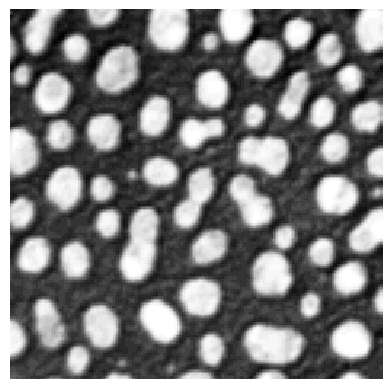

In [2]:
image = imread("data/blobs.tif")
imshow(image)

## Image segmentation using thresholding
The [threshold_otsu](https://scikit-image.org/docs/dev/api/skimage.filters.html#skimage.filters.threshold_otsu) operation, also known as Otsu's method (Otsu et al., IEEE Transactions on Systems, Man, and Cybernetics, Vol. 9 (1), 1979), delivers a number: the intensity threshold that allows differentiating foreground (object) and background in the image.

In [3]:
threshold = filters.threshold_otsu(image)

When using methods such as thresholding in notebooks, it is recommended to print out the result to see what it actually returns. Here, we are using the method from scikit-image, which returns the threshold that is applied. Printing that threshold can be helpful later when reproducing the workflow, also if others want to apply the same threshold to the dataset in other software.

In [4]:
threshold

np.int64(120)

Using numpy arrays, we can apply the threshold by applying the `>=` operator. The result will be a binary image.

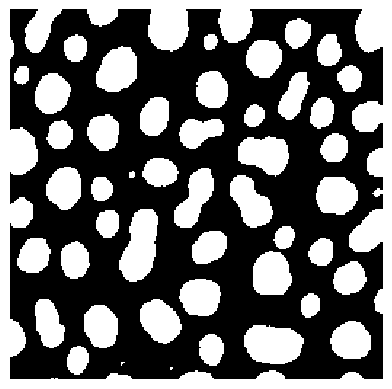

In [5]:
binary_image = image >= threshold

imshow(binary_image)

We can also determine in which type the binary image is processed by printing out minimum and maximum of the image:

In [6]:
binary_image.max()

np.True_

In [7]:
binary_image.min()

np.False_

As shown earlier, matplotlib allows us to draw an outline on top of an image visualized using `imshow` using the `contour` command.

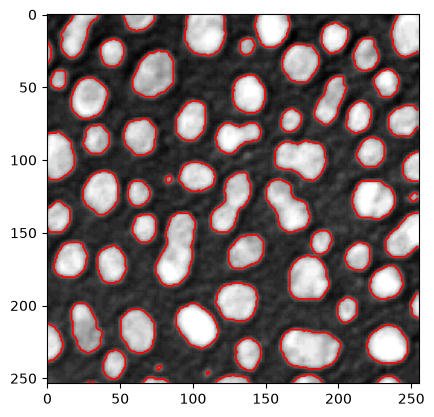

In [8]:
# create a new plot
fig, axes = plt.subplots(1,1)

# add two images
axes.imshow(image, cmap=plt.cm.gray)
axes.contour(binary_image, [0.5], linewidths=1.2, colors='r')

There is a list of [thresholding algorithms](https://scikit-image.org/docs/dev/auto_examples/segmentation/plot_thresholding.html) available. It is possible to apply them all to your data and see differences:

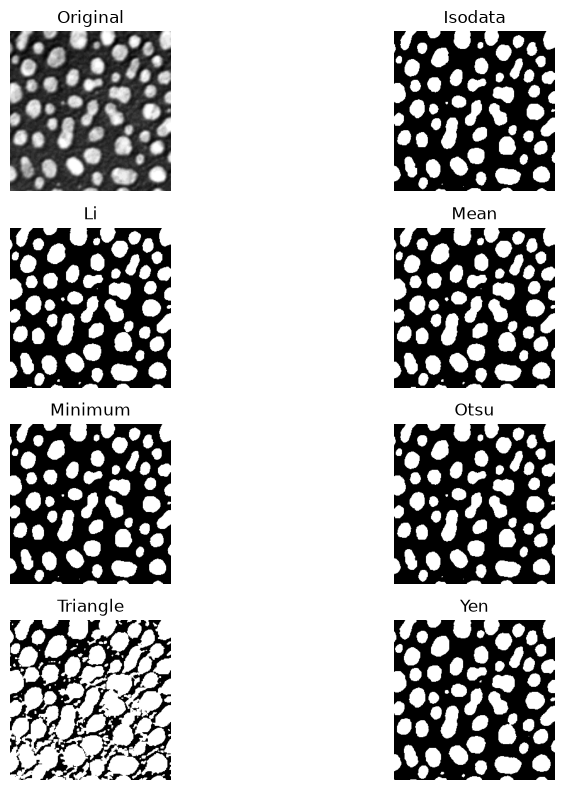

In [9]:
fig, ax = try_all_threshold(image, figsize=(10, 8), verbose=False)
plt.show()

## Thresholding using pyclesperanto
Furthermore, also other libraries such as [pyclesperanto](https://github.com/clesperanto/pyclesperanto/) offer thresholding algorithms. The implementation here does not return the threshold, it directly returns the binary image.

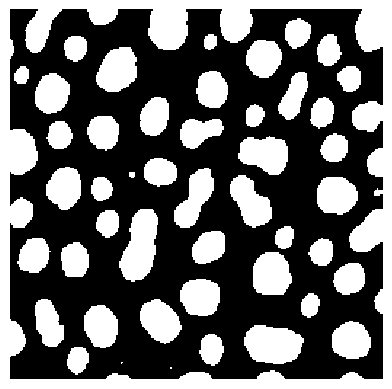

In [10]:
import pyclesperanto as cle

binary_image2 = cle.threshold_otsu(image)
imshow(binary_image2)

Here we can also see that different libraries store binary images in different ways. pyclesperanto for example stores the positive pixels in binary images not as `True` but with a `1` instead:

In [11]:
binary_image2.max()

1.0

In [12]:
binary_image2.min()

0.0

# Exercise
Segment blobs.tif using the Yen algorithm.

Subtract the Yen-segmented image from the Otsu-segmented image and visualize the result.

Repeat the same for the image `data/banana/banana0002.tif`.